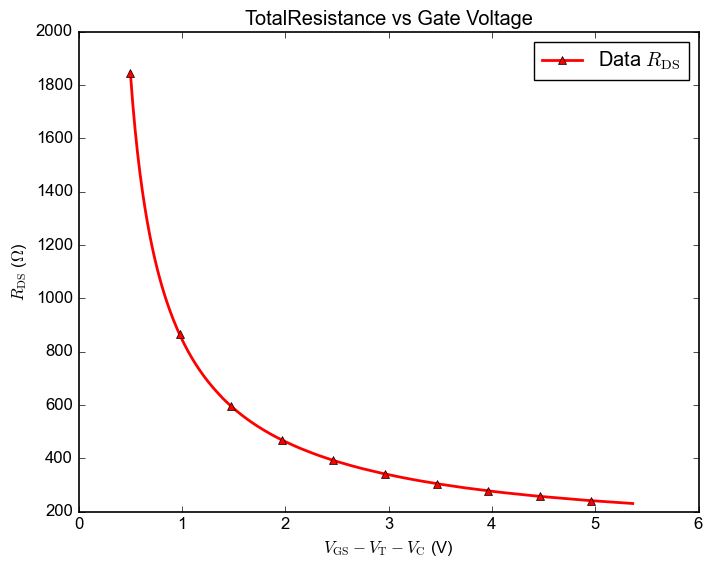

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

# IDS - VGS data
data = np.loadtxt("./Mobility/20262004004.dat")
V_GS = data[:, 0]  # VGS values
I_DS = data[:, 2]  # IDS values
V_DS = data[:, 3]  # VDS values
sigma = data[:, 7]

V_C = 0.5*(data[:, 4] + data[:, 5])
R_DS = V_DS / I_DS  # Calculate resistance
V_T = 0.644
Ci = 1e-2 # F/m^2
mu = 760e-4	# m^2/Vs

x = V_GS - V_T - V_C

plt.plot(x, R_DS, lw=2, label=r'Data $R_\text{DS}$', color='red', marker='^', linestyle='-', markevery=40)
plt.xlabel(r"$V_\text{GS}- V_\text{T} - V_\text{C}$ (V)")
plt.ylabel(r"$R_\text{DS}$ ($\Omega$)")
# plt.xlim(5,30)
# plt.ylim(50, 150)
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("TotalResistance vs Gate Voltage")
plt.show()

a = 65.1987 ± 1.69
b = 812.131 ± 2.72
R^2 = 0.995626
--------------------------------------
Rc = (65.1987 ± 1.69) Ω


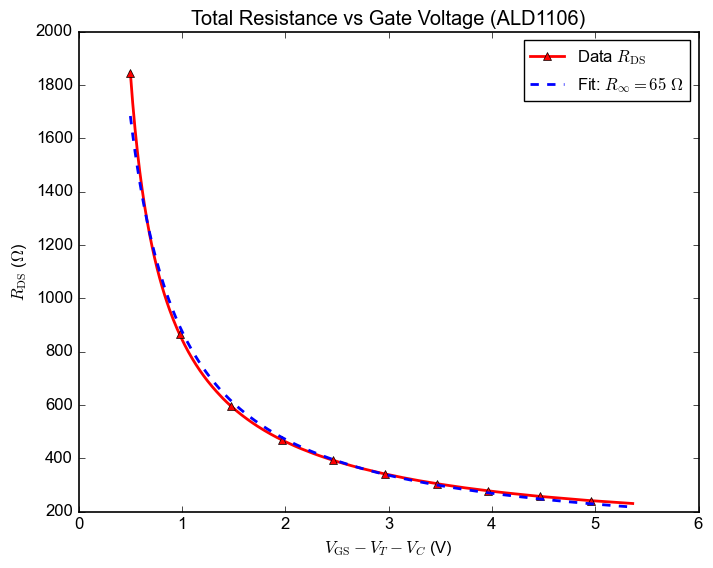

In [ ]:
def func(x, a, b):
    return a + b / x

# Use only finite points in the requested fit window: 5 <= -x <= 30
mask = np.isfinite(x) & np.isfinite(R_DS)
x_fit = x[mask]
R_fit_data = R_DS[mask]


# Fit Rc + b/x to the selected x-range
popt, pcov = curve_fit(
    func,
    x_fit,
    R_fit_data,
)
R_fit = func(x_fit, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((R_fit_data - R_fit) ** 2)
ss_tot = np.sum((R_fit_data - np.mean(R_fit_data)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr



R_fit = func(x_fit, a, b)


print(f"a = {a:.6g} ± {a_err:.3g}")
print(f"b = {b:.6g} ± {b_err:.3g}")
print(f"R^2 = {r2:.6f}")
print("--------------------------------------")
print(f"Rc = ({a:.6g} ± {a_err:.3g}) Ω")

# x_test = np.linspace(-50, -15, 100)
# R_test = func(x_test, a, b)

plt.plot(x, R_DS, lw=2, label=r'Data $R_\text{DS}$', color='red', marker='^', linestyle='-', markevery=40)
plt.plot(x_fit, R_fit, lw=2, label=rf'Fit: $R_\infty = {a:.2g}$ $\Omega$', color='blue', linestyle='--')
# plt.plot(-x_test, R_test*1e-6, lw=2, label=rf'Test: $R_C = {a*1e-6:.2g}$ M$\Omega$', color='green', linestyle='-.')
plt.xlabel(r"$V_\text{GS}- V_T - V_C$ (V)")
plt.ylabel(r"$R_\text{DS}$ ($\Omega$)")
# plt.xlim(5,30)
# plt.ylim(50, 150)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=12)
plt.title("Total Resistance vs Gate Voltage (ALD1106)")
# plt.savefig("resistance_gvdP.eps", format='eps', bbox_inches='tight')
plt.show()